In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
df=pd.read_csv("Cleaned_dataset.csv")


In [6]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [7]:
#remove unnessury features
df.drop(['day','month','year','classes','region'],axis=1,inplace=True)

In [8]:
#i/p and d/p features 
X=df.drop('FWI',axis=1)
Y=df['FWI']
X.info()
Y.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  243 non-null    int64  
 1   RH           243 non-null    int64  
 2   Ws           243 non-null    int64  
 3   Rain         243 non-null    float64
 4   FFMC         243 non-null    float64
 5   DMC          243 non-null    float64
 6   DC           243 non-null    float64
 7   ISI          243 non-null    float64
 8   BUI          243 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 17.2 KB
<class 'pandas.Series'>
RangeIndex: 243 entries, 0 to 242
Series name: FWI
Non-Null Count  Dtype  
--------------  -----  
243 non-null    float64
dtypes: float64(1)
memory usage: 2.0 KB


In [9]:
#split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)
X_train.info()

<class 'pandas.DataFrame'>
Index: 182 entries, 97 to 102
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  182 non-null    int64  
 1   RH           182 non-null    int64  
 2   Ws           182 non-null    int64  
 3   Rain         182 non-null    float64
 4   FFMC         182 non-null    float64
 5   DMC          182 non-null    float64
 6   DC           182 non-null    float64
 7   ISI          182 non-null    float64
 8   BUI          182 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 14.2 KB


In [ ]:
#scale


<Axes: >

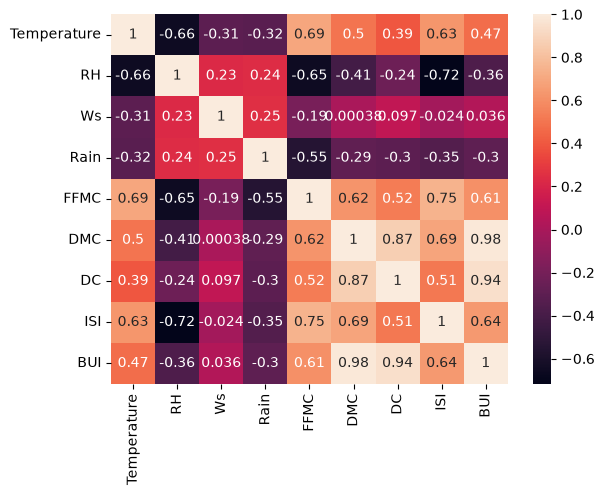

In [10]:
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [11]:
def coreficent(dataset,threshold):
    coff=set()
    corr=dataset.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i,j]*100)>threshold:
                colname=corr.columns[i]
                coff.add(colname)
    return coff




In [12]:
coef_reomve=coreficent(X_train,85)


In [13]:
print(coef_reomve)

{'DC', 'BUI'}


In [14]:
X_train.drop(coef_reomve,axis=1,inplace=True)

In [15]:

X_test.drop(coef_reomve,axis=1,inplace=True)

In [29]:
X_train.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'ISI'], dtype='str')

In [16]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scale=scaler.fit_transform(X_train)
X_test_scale=scaler.transform(X_test)

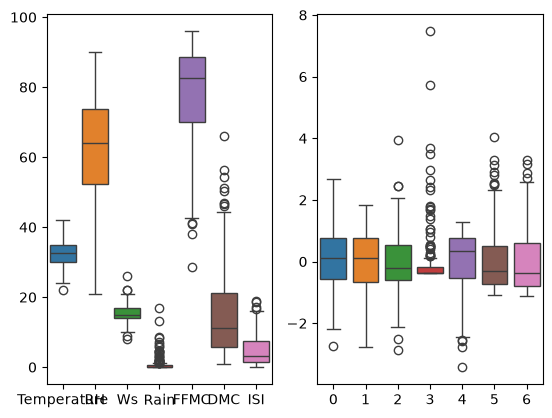

In [17]:

plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scale)
plt.show()

In [18]:
from sklearn.linear_model import LinearRegression
lin=LinearRegression()
lin.fit(X_train_scale,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[-0.01, 0.09, 0.05,...,-0.55, 3.68, 5.02]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.156
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[26.37,14.35,12.21,..., 7.91, 6.09, 5.64]"


In [19]:
y_pred=lin.predict(X_test_scale)


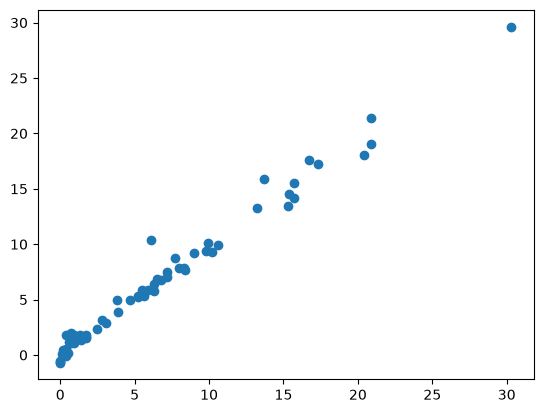

In [20]:
plt.scatter(Y_test,y_pred)

In [21]:
from sklearn.metrics import r2_score
r2=r2_score(Y_test,y_pred)
print(r2)


0.9804976435240779


In [22]:
from sklearn.linear_model import Lasso
lasso=Lasso()
lasso.fit(X_train_scale,Y_train)
e_pred=lasso.predict(X_test_scale)
r2=r2_score(Y_test,e_pred)
print(r2)


0.9492020263112388


In [23]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(X_train_scale,Y_train)
r_pred=ridge.predict(X_test_scale)
r2=r2_score(Y_test,r_pred)
print(r2)

0.9798296003877378


In [24]:
from sklearn.linear_model import ElasticNet
en=ElasticNet()
en.fit(X_train_scale,Y_train)
n_pred=en.predict(X_test_scale)
r2=r2_score(Y_test,n_pred)
print(r2)

0.868664603256521


0.2311350356393118
0.9708498092442305


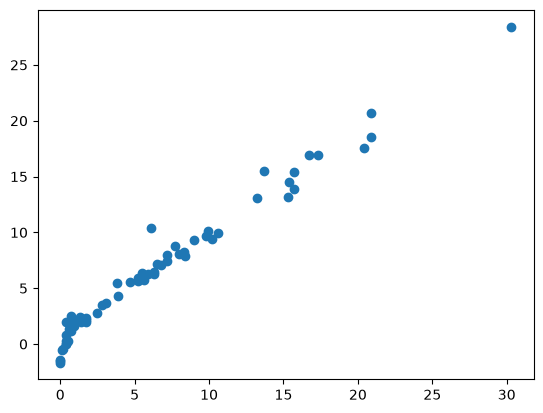

In [25]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scale,Y_train)
print(lassocv.alpha_)
model=lassocv.predict(X_test_scale)
plt.scatter(Y_test,model)
r2=r2_score(Y_test,model)
print(r2)


10.0
0.9714727935735807


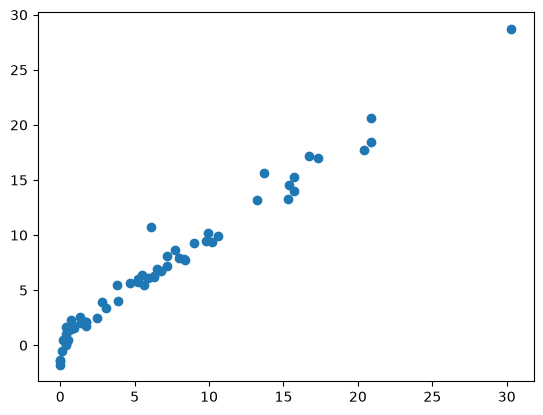

In [27]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scale,Y_train)
print(ridgecv.alpha_)
modelr=ridgecv.predict(X_test_scale)
plt.scatter(Y_test,modelr)
r2=r2_score(Y_test,modelr)
print(r2)


0.868664603256521


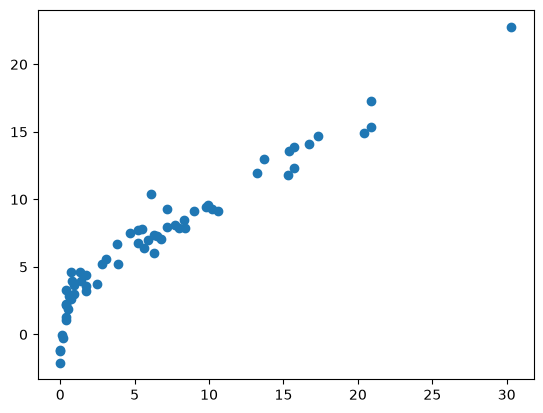

In [26]:
from sklearn.linear_model import ElasticNet
encv=ElasticNet()
encv.fit(X_train_scale,Y_train)

modelen=encv.predict(X_test_scale)
plt.scatter(Y_test,modelen)
r2=r2_score(Y_test,modelen)
print(r2)


In [27]:
import pickle
pickle.dump(lin,open("Linear.pkl","wb"))

In [28]:
pickle.dump(scaler,open("scaler.pkl","wb"))